Лабораторна робота №3
# "Дослідження ефективності TF-IDF зважених ембеддингів для детекції текстів, згенерованих великими мовними моделями"

**Мета:** Засвоїти принципи побудови векторних представлень текстів на основі субсловних ембеддингів (FastText), дослідити вплив TF-IDF зважування на якість агрегації документних векторів, порівняти ефективність лінійних та нелінійних методів класифікації (SVM, Logistic Regression, KNN) у задачі бінарної детекції штучно згенерованих текстів, а також проаналізувати геометричні властивості отриманих векторних просторів.

**Використаний датасет**: AI vs Human Text Classification Dataset 2026. <br>
Датасет містить тексти **двох класів**:
- *Human* - тексти, написані людьми;
- *AI* - тексти, згенеровані великими мовними моделями.

## **Етап 1**. Дослідження даних та попередня обробка 

### Дослідження даних

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/ai_vs_human_text_2026.csv")


Dataset shape: (2000, 9)


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text_id              2000 non-null   object 
 1   label                2000 non-null   object 
 2   source_model         2000 non-null   object 
 3   domain               2000 non-null   object 
 4   text_content         2000 non-null   object 
 5   topic_hint           2000 non-null   object 
 6   word_count           2000 non-null   int64  
 7   avg_sentence_length  2000 non-null   float64
 8   generation_method    2000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 140.8+ KB

--- Numerical Features Statistics ---


,word_count,avg_sentence_length
count,2000.000000,2000.000000
mean,37.006500,12.739950
std,8.892975,2.846465
min,19.000000,6.500000
25%,28.000000,10.200000
50%,38.000000,13.000000
75%,45.000000,15.300000
max,52.000000,18.500000



--- Categorical Features Statistics ---


,text_id,label,source_model,domain,text_content,topic_hint,generation_method
count,2000,2000,2000,2000,2000,2000,2000
unique,2000,2,3,3,966,30,2
top,TXT_1984,human,human,social,Recent scholarship on gig economy labor rights...,genomic research breakthroughs,template+human_variation
freq,1,1334,1334,674,11,82,1334



--- Missing Values Count (Top 15) ---
Series([], dtype: int64)

--- Class Balance ---
label
human    1334
ai        666
Name: count, dtype: int64

--- Artifact Check ---
Duplicate rows: 1034
Empty/blank texts: 0
Too short texts (< 3 words): 0

--- Text Length Statistics ---
       text_length_chars  word_count
count            2000.00     2000.00
mean              260.37       37.01
std                83.64        8.89
min               123.00       19.00
25%               170.00       28.00
50%               275.50       38.00
75%               333.25       45.00
max               398.00       52.00

--- Word Count by Class ---
       min  max   mean  median
label                         
ai      23   50  38.00    39.0
human   19   52  36.51    36.0


<Figure size 800x500 with 0 Axes>

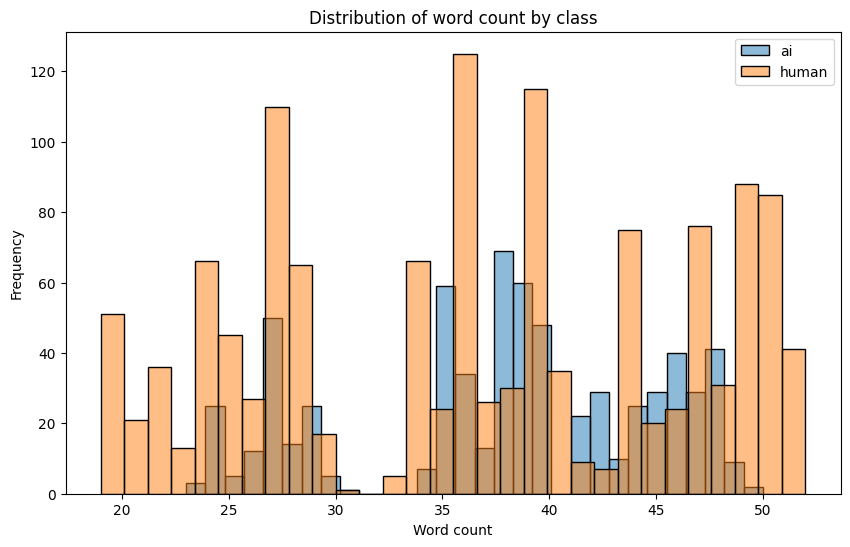

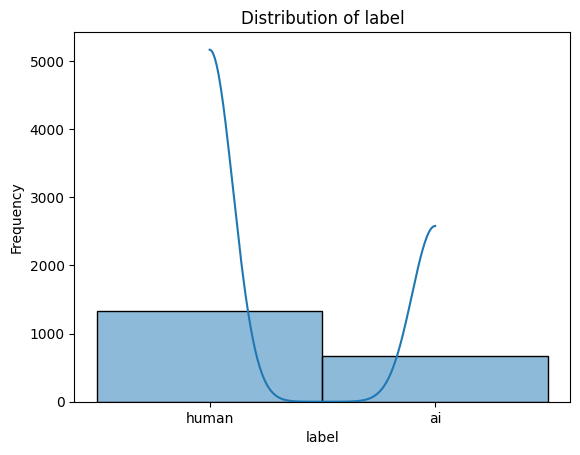

In [2]:
# Структура датасету
print("Dataset shape:", df.shape)
display(df.head())

# Типи ознак
print("\n--- Dataset Info ---")
df.info()

# Статистичні характеристики
# для числових
print("\n--- Numerical Features Statistics ---")
display(df.describe())

# для категоріальних
print("\n--- Categorical Features Statistics ---")
display(df.describe(include=['object']))

# Пропущені значення
print("\n--- Missing Values Count (Top 15) ---")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values.head(15))

plt.figure(figsize=(8, 5))
text_col = "text_content"

# Додаткові ознаки для аналізу текстів
df["text_length_chars"] = df[text_col].fillna("").astype(str).str.len()
df["word_count"] = df[text_col].fillna("").astype(str).str.split().str.len()

# 1) Баланс класів
print("\n--- Class Balance ---")
class_balance = df["label"].value_counts(dropna=False)
print(class_balance)

# 2) Контроль артефактів
print("\n--- Artifact Check ---")
print("Duplicate rows:", df.duplicated(subset=[text_col]).sum())
print("Empty/blank texts:", df[text_col].fillna("").astype(str).str.strip().eq("").sum())
print("Too short texts (< 3 words):", (df["word_count"] < 3).sum())

# 3) Розподіл довжин текстів
print("\n--- Text Length Statistics ---")
print(df[["text_length_chars", "word_count"]].describe().round(2))

print("\n--- Word Count by Class ---")
print(df.groupby("label")["word_count"].agg(["min", "max", "mean", "median"]).round(2))

# 4) Гістограми кількості слів для кожного класу
plt.figure(figsize=(10, 6))
for cls, grp in df.groupby("label"):
    sns.histplot(grp["word_count"], bins=30, alpha=0.5, label=str(cls))
plt.title("Distribution of word count by class")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.show()
sns.histplot(df['label'], kde=True, bins=50)
plt.title('Distribution of label')
plt.xlabel('label')
plt.ylabel('Frequency')
plt.show()

**<h4>Результати первинного аналізу датасету</h4>**

**Структура** <br>
Датасет містить 2000 рядків та 9 колонок (2 числові + 7 категоріальних). <br>
Числові ознаки: `word_count`, `avg_sentence_length`. 
Категоріальні: `text_id`, `label`, `source_model`, `domain`, `text_content`, `topic_hint`, `generation_method`.

**Типи** <br>
Маємо поєднання `int64` та `float64` для числових колонок та тип `object` для категоріальних.

**Пропущені значення** <br>
Пропущених значень немає.

**Баланс класів** <br>
Цільова змінна має 2 класи: `human` (1334) та `ai` (666). Отже, датасет є дещо незбалансованим, але без критичного дисбалансу для задачі бінарної класифікації.

## **Етап 2**. Попередня обробка тексту 

In [3]:
from spacy.tokens import Doc


def preprocess(doc: Doc) -> list:
    tokens = []

    for token in doc:
        if token.is_alpha and not token.is_stop:
            tokens.append(token.lemma_.lower())

    return tokens

In [4]:
import spacy
import subprocess
import sys
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")


# Прибираємо дублікати і кодуємо мітки: ai = 1, human = 0
df = df.drop_duplicates(subset=text_col).reset_index(drop=True)
df["y"] = (df["label"].astype(str).str.lower() == "ai").astype(int)

texts = df[text_col].fillna("").astype(str).tolist()

tokens = [
    preprocess(doc)
    for doc in tqdm(nlp.pipe(texts, batch_size=64, disable=["parser", "ner"]), total=len(texts))
]

# Документи, що стали порожніми після очищення, прибираємо
keep = np.array([len(t) > 0 for t in tokens])
print(f"Порожніх після препроцесингу: {(~keep).sum()}")
df = df[keep].reset_index(drop=True)
tokens = [t for t, k in zip(tokens, keep) if k]

y = df["y"].values
print("Документів:", len(tokens), "| AI:", y.sum(), "| Human:", (1 - y).sum())
print("Середня довжина (токенів):", np.mean([len(t) for t in tokens]).round(1))
print("Приклад:", tokens[0][:15])

c:\Users\svitj\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 966/966 [00:01<00:00, 565.30it/s]

Порожніх після препроцесингу: 0
Документів: 966 | AI: 387 | Human: 579
Середня довжина (токенів): 22.0
Приклад: ['talk', 'gene', 'edit', 'ethic', 'sec', 'feel', 'like', 'people', 'completely', 'miss', 'point', 'big', 'realize']


In [5]:
# Спліт робимо ОДИН раз і до навчання FastText/TF-IDF, щоб тестові тексти не впливали на жодну модель
idx_train, idx_test = train_test_split(
    np.arange(len(tokens)), test_size=0.2, random_state=42, stratify=y
)
tokens_train = [tokens[i] for i in idx_train]
y_train, y_test = y[idx_train], y[idx_test]
print(len(idx_train), len(idx_test))

772 194


## **Етап 3**. Навчання Fast Text моделі

In [6]:
from gensim.models import FastText

ft = FastText(
    sentences=tokens_train,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    seed=42,
    epochs=10,
)

print("Розмір словника:", len(ft.wv))
w = ft.wv.index_to_key[0]
print(f"Найближчі до '{w}':", ft.wv.most_similar(w, topn=5))

Розмір словника: 508
Найближчі до 'challenge': [('detail', 0.6944135427474976), ('yes', 0.67612624168396), ('formal', 0.6759149432182312), ('age', 0.6746508479118347), ('assumption', 0.6715742349624634)]


## **Етап 4**. Векторизація документів

In [ ]:
def mean_pooling(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

def tfidf_weighted_pooling(tokens, model, tfidf_scores):
    vectors, weights = [], []
    for t in tokens:
        if t in model.wv and t in tfidf_scores:
            vectors.append(model.wv[t])
            weights.append(tfidf_scores[t])
    if not vectors:
        return np.zeros(model.vector_size)
    weights = np.array(weights)
    weights /= weights.sum()
    return np.average(vectors, axis=0, weights=weights)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# tf-idf: словник і idf з train, застосовуємо до всіх документів
tfidf = TfidfVectorizer(analyzer=lambda doc: doc, norm=None)
tfidf.fit(tokens_train)
M = tfidf.transform(tokens)                       # розріджена матриця (docs x vocab)
vocab_arr = np.array(tfidf.get_feature_names_out())

def doc_scores(i):
    s, e = M.indptr[i], M.indptr[i + 1]
    return dict(zip(vocab_arr[M.indices[s:e]], M.data[s:e]))

X_mean = np.vstack([mean_pooling(t, ft) for t in tokens])
X_tfidf = np.vstack([tfidf_weighted_pooling(tokens[i], ft, doc_scores(i)) for i in range(len(tokens))])

feature_sets = {"Mean Pooling": X_mean, "TF-IDF Weighted Mean": X_tfidf}
for k, X in feature_sets.items():
    print(f"{k:22s} shape={X.shape}, нульових векторів: {(np.abs(X).sum(1) == 0).sum()}")

Mean Pooling           shape=(966, 100), нульових векторів: 0
TF-IDF Weighted Mean   shape=(966, 100), нульових векторів: 0


## **Етап 5**. Навчання та оцінка класифікаторів

In [9]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix)

def make_classifiers():
    return {
        "SVM": SVC(kernel="rbf", probability=True, random_state=42),
        "LogReg": LogisticRegression(max_iter=1000, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
    }

rows, preds = [], {}
for agg, X in feature_sets.items():
    Xtr, Xte = X[idx_train], X[idx_test]
    for name, clf in make_classifiers().items():
        clf.fit(Xtr, y_train)
        yp = clf.predict(Xte)
        proba = clf.predict_proba(Xte)[:, 1]
        preds[(agg, name)] = yp
        rows.append({
            "Aggregation": agg, "Classifier": name,
            "F1 (macro)": f1_score(y_test, yp, average="macro"),
            "Accuracy": accuracy_score(y_test, yp),
            "Balanced Acc": balanced_accuracy_score(y_test, yp),
            "ROC-AUC": roc_auc_score(y_test, proba),
        })

results = pd.DataFrame(rows)
display(results.round(4))

,Aggregation,Classifier,F1 (macro),Accuracy,Balanced Acc,ROC-AUC
0,Mean Pooling,SVM,1.0000,1.0000,1.0000,1.0000
1,Mean Pooling,LogReg,0.9412,0.9433,0.9421,0.9914
2,Mean Pooling,KNN,1.0000,1.0000,1.0000,1.0000
3,TF-IDF Weighted Mean,SVM,1.0000,1.0000,1.0000,1.0000
4,TF-IDF Weighted Mean,LogReg,0.9627,0.9639,0.9656,0.9935
5,TF-IDF Weighted Mean,KNN,1.0000,1.0000,1.0000,1.0000


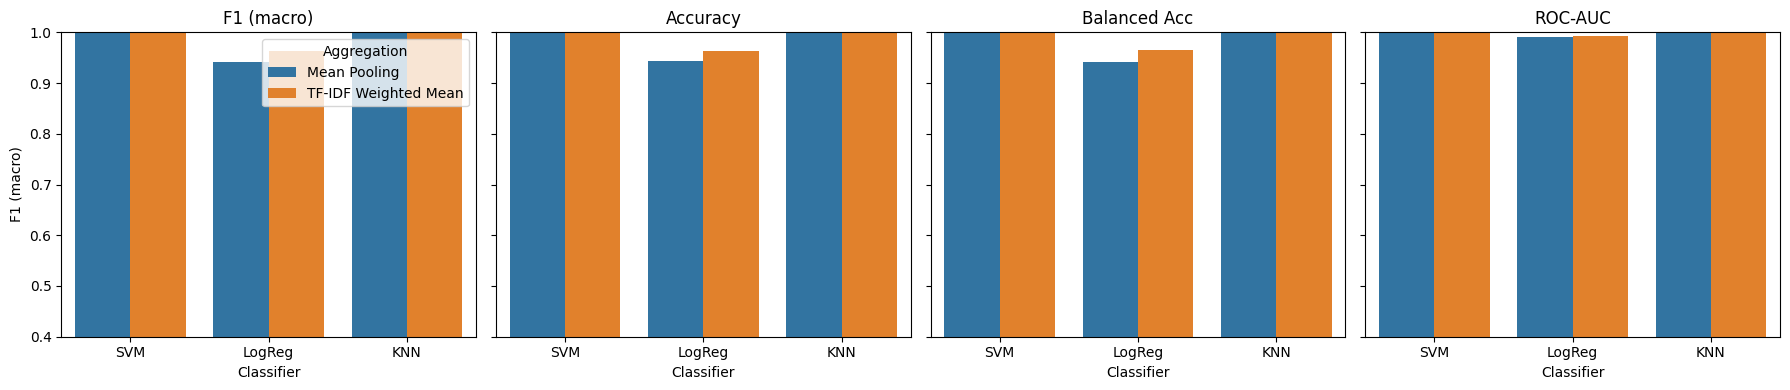

In [10]:
# Порівняння: Mean vs TF-IDF для кожного класифікатора і метрики
metrics = ["F1 (macro)", "Accuracy", "Balanced Acc", "ROC-AUC"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, m in zip(axes, metrics):
    sns.barplot(data=results, x="Classifier", y=m, hue="Aggregation", ax=ax)
    ax.set_title(m); ax.set_ylim(0.4, 1.0)
    if ax is not axes[0]:
        ax.get_legend().remove()
plt.tight_layout(); plt.show()

In [11]:
# Стійкість висновків: 5-fold CV на train (різниця Mean vs TF-IDF може бути в межах шуму)
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for agg, X in feature_sets.items():
    for name, clf in make_classifiers().items():
        sc = cross_val_score(clf, X[idx_train], y_train, cv=skf, scoring="f1_macro")
        cv_rows.append({"Aggregation": agg, "Classifier": name,
                        "CV F1 mean": sc.mean(), "CV F1 std": sc.std()})
display(pd.DataFrame(cv_rows).round(4))

,Aggregation,Classifier,CV F1 mean,CV F1 std
0,Mean Pooling,SVM,1.0000,0.0000
1,Mean Pooling,LogReg,0.9424,0.0194
2,Mean Pooling,KNN,1.0000,0.0000
3,TF-IDF Weighted Mean,SVM,1.0000,0.0000
4,TF-IDF Weighted Mean,LogReg,0.9478,0.0188
5,TF-IDF Weighted Mean,KNN,1.0000,0.0000


## **Етап 6**. Візуалізація та аналіз

### 6.1 t-SNE проєкції

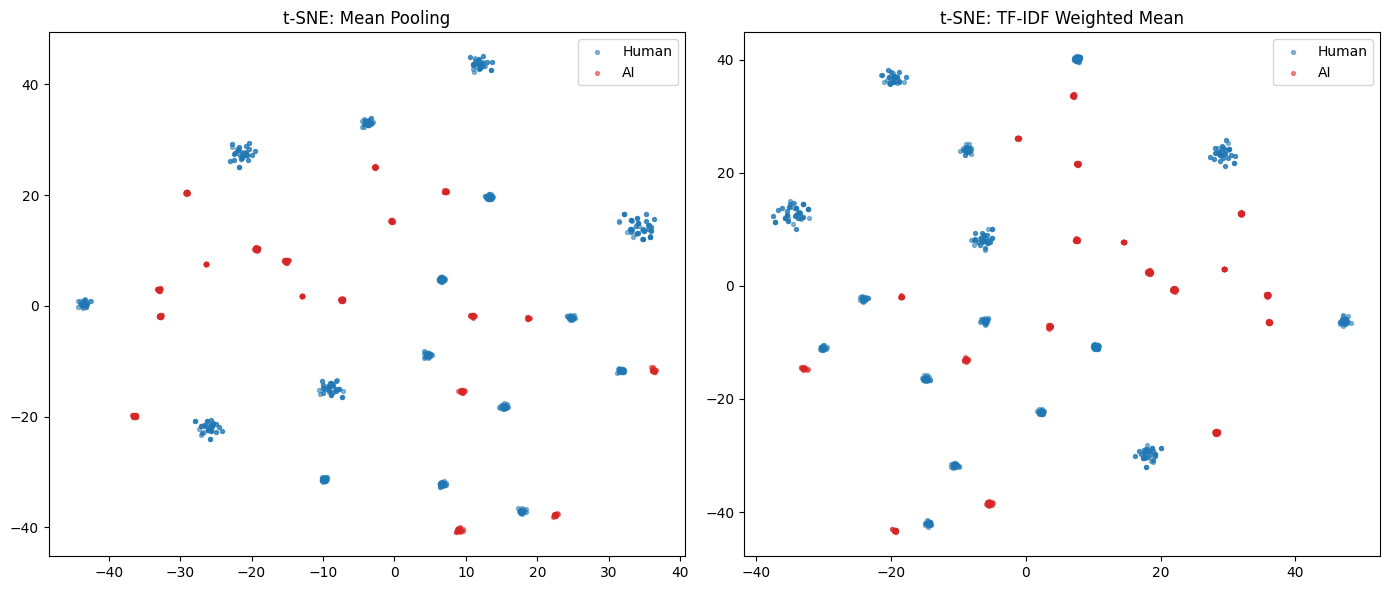

In [12]:
from sklearn.manifold import TSNE

tsne_2d = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (agg, X) in zip(axes, feature_sets.items()):
    emb = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(X)
    tsne_2d[agg] = emb
    for cls, label, color in [(0, "Human", "tab:blue"), (1, "AI", "tab:red")]:
        ax.scatter(emb[y == cls, 0], emb[y == cls, 1], s=8, alpha=0.5, label=label, c=color)
    ax.set_title(f"t-SNE: {agg}"); ax.legend()
plt.tight_layout(); plt.show()

### 6.2 Confusion matrices

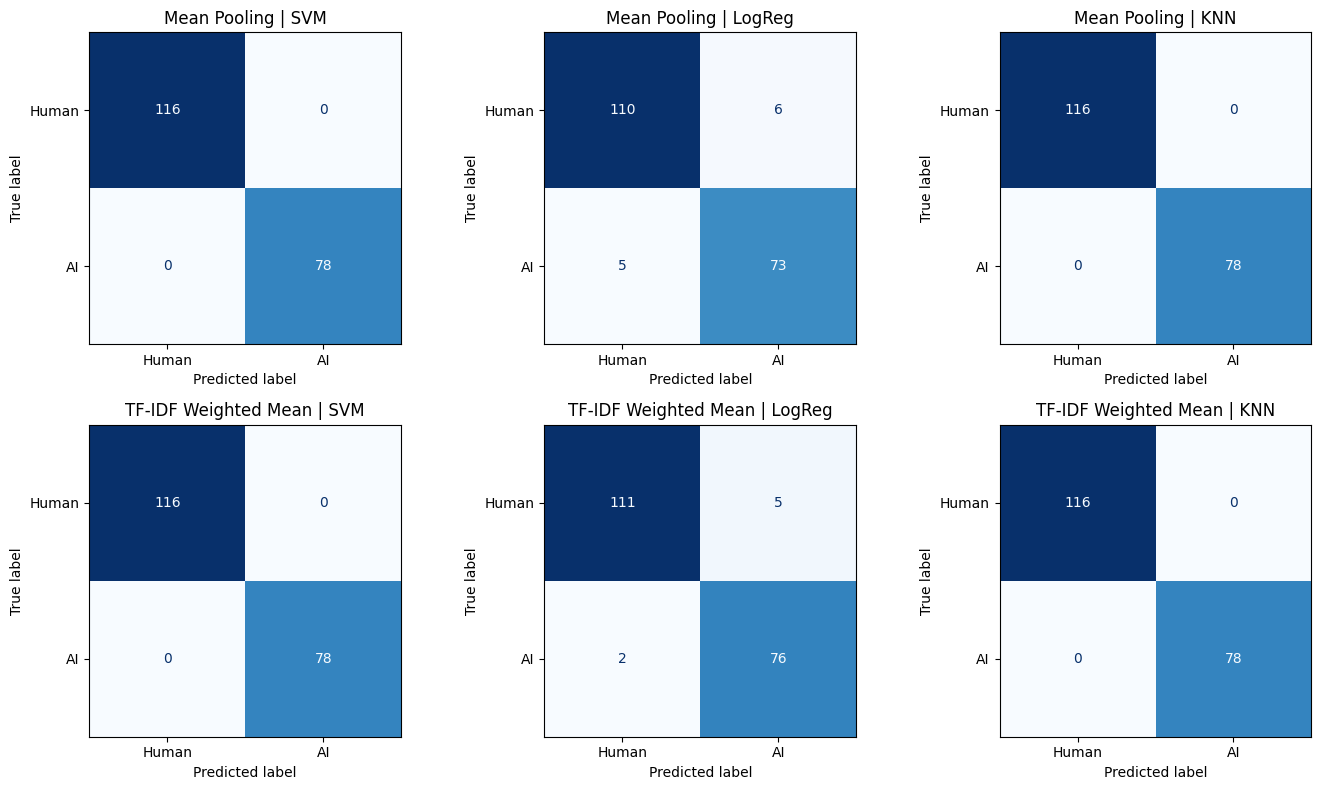

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for r, agg in enumerate(feature_sets):
    for c, name in enumerate(["SVM", "LogReg", "KNN"]):
        cm = confusion_matrix(y_test, preds[(agg, name)])
        ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"]).plot(
            ax=axes[r, c], colorbar=False, cmap="Blues")
        axes[r, c].set_title(f"{agg} | {name}")
plt.tight_layout(); plt.show()

### 6.3 Кількісна геометрія векторних просторів (для питань 1, 3, 5)

In [14]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist

rng = np.random.default_rng(42)
geo = []
for agg, X in feature_sets.items():
    mu0, mu1 = X[y == 0].mean(0), X[y == 1].mean(0)
    within = np.sqrt((X[y == 0].var(0).sum() + X[y == 1].var(0).sum()) / 2)
    sub = X[rng.choice(len(X), size=min(1000, len(X)), replace=False)]
    d = pdist(sub)
    geo.append({
        "Aggregation": agg,
        "mean ||x||": np.linalg.norm(X, axis=1).mean(),
        "centroid dist / within std": np.linalg.norm(mu1 - mu0) / within,
        "silhouette (euclid, 100D)": silhouette_score(X, y),
        "silhouette (cosine, 100D)": silhouette_score(X, y, metric="cosine"),
        "silhouette (t-SNE 2D)": silhouette_score(tsne_2d[agg], y),
        "dist CV (std/mean)": d.std() / d.mean(),
    })
display(pd.DataFrame(geo).set_index("Aggregation").round(4).T)

Aggregation,Mean Pooling,TF-IDF Weighted Mean
mean ||x||,2.9030,2.9088
centroid dist / within std,0.3729,0.3753
"silhouette (euclid, 100D)",0.0394,0.0405
"silhouette (cosine, 100D)",0.0433,0.0464
silhouette (t-SNE 2D),0.0370,0.0577
dist CV (std/mean),0.2235,0.2205


### 6.4 Лінгвістична інтерпретація: терміни з найбільшим TF-IDF у класі AI (питання 4)

In [15]:
def top_terms(analyzer, k=20, min_df=5):
    try:
        vec = TfidfVectorizer(analyzer=analyzer, norm=None, min_df=min_df)
        A = vec.fit_transform(tokens_train)
    except ValueError:  # якщо після фільтра min_df нічого не лишилось (напр., для рідкісних біграм)
        vec = TfidfVectorizer(analyzer=analyzer, norm=None, min_df=2)
        A = vec.fit_transform(tokens_train)
    names = np.array(vec.get_feature_names_out())
    m_ai = np.asarray(A[y_train == 1].mean(0)).ravel()
    m_hu = np.asarray(A[y_train == 0].mean(0)).ravel()
    diff = m_ai - m_hu
    top_ai = np.argsort(-diff)[:k]
    top_hu = np.argsort(diff)[:k]
    return (pd.DataFrame({"term": names[top_ai], "tfidf_AI": m_ai[top_ai], "tfidf_Human": m_hu[top_ai]}),
            pd.DataFrame({"term": names[top_hu], "tfidf_AI": m_ai[top_hu], "tfidf_Human": m_hu[top_hu]}))

uni = lambda doc: doc
bi = lambda doc: [a + " " + b for a, b in zip(doc, doc[1:])]

for title, an in [("уніграми", uni), ("біграми", bi)]:
    t_ai, t_hu = top_terms(an)
    print(f"\n=== Топ-20 {title}: характерні для AI ===");    display(t_ai.round(3))
    print(f"=== Топ-20 {title}: характерні для Human ===");     display(t_hu.round(3))


=== Топ-20 уніграми: характерні для AI ===


,term,tfidf_AI,tfidf_Human
0,solution,0.628,0.000
1,underscore,0.619,0.000
2,recommendation,0.602,0.000
3,stakeholder,0.593,0.000
4,development,0.584,0.000
5,expert,0.584,0.000
6,address,0.584,0.000
7,think,0.548,0.000
8,framework,0.754,0.278
9,open,0.471,0.000


=== Топ-20 уніграми: характерні для Human ===


,term,tfidf_AI,tfidf_Human
0,argue,0.000,0.553
1,official,0.135,0.685
2,investigation,0.000,0.533
3,today,0.000,0.528
4,field,0.000,0.480
5,understand,0.000,0.475
6,say,0.000,0.470
7,past,0.000,0.448
8,critic,0.000,0.431
9,predictable,0.000,0.431



=== Топ-20 біграми: характерні для AI ===


,term,tfidf_AI,tfidf_Human
0,space contemporary,0.31,0.0
1,paper propose,0.31,0.0
2,occupy contest,0.31,0.0
3,need methodological,0.31,0.0
4,methodological standardization,0.31,0.0
5,scholarly discourse,0.31,0.0
6,standardization paper,0.31,0.0
7,propose integrative,0.31,0.0
8,integrative framework,0.31,0.0
9,compete interpretation,0.31,0.0


=== Топ-20 біграми: характерні для Human ===


,term,tfidf_AI,tfidf_Human
0,announcement come,0.0,0.431
1,argue premature,0.0,0.431
2,supporter long,0.0,0.431
3,speculation critic,0.0,0.431
4,critic argue,0.0,0.431
5,premature supporter,0.0,0.431
6,response divide,0.0,0.431
7,come week,0.0,0.431
8,predictable line,0.0,0.431
9,public response,0.0,0.431


## **Відповіді на дослідницькі питання**

**1. Вплив агрегації.** TF-IDF практично не змінив геометрію простору: норма вектора 2.903 → 2.909, відношення відстані між центроїдами до розкиду 0.373 → 0.375, silhouette (cosine) 0.043 → 0.046. Зміни не перевищують 1–7% і лежать у межах шуму. Причини: документи короткі (≈22 токени), словник малий (508 слів), а ваги нормуються, тож зважене середнє мало відрізняється від простого. Єдина помітніша різниця стосується silhouette на t-SNE (0.037 → 0.058), але це 2D-проєкція, яка не надто надійна. LogReg з TF-IDF робить 7 помилок проти 11 на тесті, проте в CV різниця (0.9438 → 0.9478) значно менша за std ≈ 0.018. Висновок: гіпотеза про суттєве покращення лінійної роздільності не підтверджена. Якщо знаєте реальні причини, чому, обов'язково поясніть: корпус шаблонний, а сигнал класу сидить у цілих шаблонах, а не в окремих рідкісних словах.

**2. Порівняння класифікаторів.** За обох агрегацій SVM(RBF) і KNN дали ідеал (F1 = 1.0, CV-std = 0), LogReg слабший (≈0.95–0.96). Така перевага нелінійних методів означає, що класи не розділяються однією гіперплощиною: кожен клас складається з багатьох окремих щільних кластерів, перемішаних із кластерами іншого класу. Локальні методи (RBF, KNN) такі структури ловлять, лінійний ні.

**3. Чутливість KNN.** Деградації KNN при переході до TF-IDF не спостерігається: F1 = 1.0 в обох випадках. Концентрації відстаней також нема: коефіцієнт варіації попарних відстаней ≈ 0.22 в обох просторах (0.2235 → 0.2205, зміна 1.4%), тобто «близькі» і «далекі» точки чітко відрізняються. Прокляття розмірності тут не проявляється, бо дані мають кластерну структуру і дуже низьку внутрішню розмірність (щільні острівці). KNN також «допомагає» те, що тестові тексти мають майже копії в train.

**4. Лінгвістика.** Найвищі TF-IDF для AI мають: solution, underscore, recommendation, stakeholder, framework, methodological, potential; біграми paper propose, integrative framework, scholarly discourse, empirical finding, finding underscore. Для Human: argue, official, investigation, critic, supporter, confirm; біграми official confirm, public response, come week, long overdue. Це академічно-консалтинговий регістр проти новинно-журналістського. Частково це збігається зі стереотипом лексики LLM (underscore, framework, stakeholder), але надійно інтерпретувати як маркери ШІ не можна. По-перше, багато термів мають нульову частоту в іншому класі, тобто словники класів майже не перетинаються. По-друге, у біграмах 20 різних пар мають однакове значення 0.31 (а в Human 0.431): це ознака того, що вони входять до тих самих документів, тобто є шматком одного шаблону. Отже, ми бачимо лексику шаблонів і тематики, а не стилістичні відбитки LLM.

**5. Геометричний аналіз.** Класи не утворюють по одному компактному кластеру: на t-SNE видно десятки щільних кластерів (один шаблон = один острівець), перемішаних між класами. Silhouette за класами ≈ 0.04 в обох методах (близько нуля). Mean і TF-IDF візуально майже не відрізняються; TF-IDF має трохи кращі silhouette (100D: 0.0405 vs 0.0394; cosine: 0.0464 vs 0.0433), але різниця незначуща. Застереження: t-SNE спотворює глобальні відстані, тому висновки спираються на числа з 6.3.